In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../outputs")

holdout_features = pd.read_parquet(
    OUTPUT_DIR / "holdout_features.parquet"
)

graph_result = pd.read_csv(
    OUTPUT_DIR / "anomaly_graph_score.csv"
)

assert holdout_features["CustomerID"].is_unique
assert graph_result["CustomerID"].is_unique

holdout_features.shape, graph_result.shape

((20000, 119), (20000, 11))

In [2]:
def is_binary_series(s: pd.Series) -> bool:
    values = set(s.dropna().unique())
    return values.issubset({0, 1, 0.0, 1.0})


def percentile_risk(
    df: pd.DataFrame,
    col: str,
    high_is_risk: bool = True,
) -> pd.Series:
    """
    Chuyển 1 feature về risk score [0, 1]

    high_is_risk=True:
        large value = risky

    high_is_risk=False:
        large value = trustworthy/safe
    """
    s = pd.to_numeric(df[col], errors="coerce")

    if s.isna().all():
        return pd.Series(0.0, index=df.index)

    # Median imputation
    s = s.fillna(s.median())

    # Cứ 1 là rủi ro cao nhất, 0 là an toàn nhất
    if is_binary_series(s):
        risk = s.astype(float) if high_is_risk else 1.0 - s.astype(float)
        return risk.clip(0, 1)

    # Nếu tất cả giá trị đều bẳng nhau, không có risk signal
    if s.nunique(dropna=True) <= 1:
        return pd.Series(0.0, index=df.index)

    pct = s.rank(method="average", pct=True)

    risk = pct if high_is_risk else 1.0 - pct

    return risk.clip(0, 1)


def weighted_mean_risk(
    df: pd.DataFrame,
    specs: list[tuple[str, bool, float]],
    prefix: str,
) -> tuple[pd.Series, pd.DataFrame]:
    """
    specs = [(feature_name, high_is_risk, weight), ...]
    """
    component_df = pd.DataFrame(index=df.index)
    weighted_sum = pd.Series(0.0, index=df.index)
    total_weight = 0.0

    for col, high_is_risk, weight in specs:
        if col not in df.columns:
            continue

        risk = percentile_risk(
            df=df,
            col=col,
            high_is_risk=high_is_risk,
        )

        component_name = f"{prefix}_{col}_risk"
        component_df[component_name] = risk

        weighted_sum += weight * risk
        total_weight += weight

    if total_weight == 0:
        pillar_risk = pd.Series(0.0, index=df.index)
    else:
        pillar_risk = weighted_sum / total_weight

    return pillar_risk.clip(0, 1), component_df

In [3]:
STRONG = 1.5
MEDIUM = 1.0
WEAK = 0.5
CONTEXT = 0.25
OBSERVATION_ONLY = 0.0


# 1. Device Integrity
# high_is_risk=True means larger value is riskier.
# high_is_risk=False means larger value is safer.

device_specs = [
    # Direct device compromise / automation signals
    ("is_emulator", True, STRONG),
    ("emulator_session_ratio", True, STRONG),
    ("is_generic_or_clone", True, STRONG),
    ("tac_grey_clone_flag", True, STRONG),

    # Device-type context: feature phones are not emulator risk by themselves.
    ("is_feature_phone", True, OBSERVATION_ONLY),

    # Rooted/jailbroken device signals
    ("is_rooted", True, MEDIUM),
    ("rooted_session_ratio", True, MEDIUM),

    # Device reputation / TAC-level risk
    ("tac_risk_score", True, MEDIUM),

    # Shared device signals
    ("high_shared_imei_flag", True, MEDIUM),
    ("max_customers_per_imei", True, MEDIUM),
    ("shared_imei_flag", True, WEAK),

    # Weaker context signals
    ("low_tier_device_flag", True, WEAK),
    ("low_tier_session_ratio", True, WEAK),
    ("num_imeis_90d", True, WEAK),
]


# 2. SIM Stability

sim_specs = [
    # Direct SIM-swap risk signals
    ("sim_swap_count_90d", True, STRONG),
    ("days_since_last_sim_swap", False, STRONG),  # smaller = riskier
    ("recent_sim_change_flag", True, STRONG),

    # Broader SIM instability signals
    ("sim_swap_count_12m", True, MEDIUM),
    ("iccid_count", True, MEDIUM),

    # Weaker context signals
    ("phone_number_age_days", False, WEAK),       # newer number = riskier
    ("port_in_flag", True, WEAK),
]


# 3. Behavioral Consistency

behavior_specs = [
    # Strong risky infrastructure / impossible-travel-like signals
    ("geo_velocity_alerts_30d", True, STRONG),
    ("datacenter_ratio_30d", True, STRONG),
    ("vpn_proxy_ratio_30d", True, STRONG),

    # Main behavioral consistency signals
    ("geo_velocity_flag_30d", True, MEDIUM),
    ("non_residential_ratio_30d", True, MEDIUM),
    ("home_cell_ratio_30d", False, MEDIUM),       # higher home stability = safer
    ("distinct_country_30d", True, MEDIUM),

    # Secondary behavior signals
    ("distinct_ip_30d", True, WEAK),
    ("night_session_ratio_30d", True, WEAK),

    # Context only: high activity may be legitimate power-user behavior
    ("avg_sessions_per_day_30d", True, CONTEXT),
    ("total_sessions_30d", True, CONTEXT),
]


# 4. Identity Confidence

identity_specs = [
    # Strong identity confidence signal
    ("kyc_level_ord", False, STRONG),

    # Main verification availability signals
    ("has_face_score", False, MEDIUM),
    ("has_iddoc_score", False, MEDIUM),

    # Match quality signals
    ("face_match_score", False, STRONG),
    ("id_doc_match_score", False, STRONG),
]

In [4]:
dts_base = holdout_features[["CustomerID"]].copy()

device_risk, device_components = weighted_mean_risk(
    holdout_features,
    device_specs,
    prefix="device",
)

sim_risk, sim_components = weighted_mean_risk(
    holdout_features,
    sim_specs,
    prefix="sim",
)

behavior_risk, behavior_components = weighted_mean_risk(
    holdout_features,
    behavior_specs,
    prefix="behavior",
)

identity_risk, identity_components = weighted_mean_risk(
    holdout_features,
    identity_specs,
    prefix="identity",
)

dts_base["device_risk"] = device_risk
dts_base["sim_risk"] = sim_risk
dts_base["behavior_risk"] = behavior_risk
dts_base["identity_risk"] = identity_risk

# Chuyển risk thành trust score: high score = more trustworthy
dts_base["device_score"] = 1000 * (1 - dts_base["device_risk"])
dts_base["sim_score"] = 1000 * (1 - dts_base["sim_risk"])
dts_base["behavior_score"] = 1000 * (1 - dts_base["behavior_risk"])
dts_base["identity_score"] = 1000 * (1 - dts_base["identity_risk"])

dts_base.head()

,CustomerID,device_risk,sim_risk,behavior_risk,identity_risk,device_score,sim_score,behavior_score,identity_score
0,3000006,0.227148,0.259387,0.378799,0.645529,772.851923,740.613333,621.201250,354.471154
1,3000018,0.220197,0.475340,0.442781,0.333981,779.802885,524.660000,557.218750,666.019231
2,3000034,0.297607,0.520685,0.390390,0.364667,702.393269,479.315000,609.610000,635.332692
3,3000070,0.129501,0.325973,0.580399,0.120138,870.499038,674.026667,419.600625,879.861538
4,3000074,0.129501,0.259593,0.484624,0.106910,870.499038,740.406667,515.375625,893.090385


In [5]:
pillar_weights = {
    "device_score": 0.25,
    "sim_score": 0.30,
    "behavior_score": 0.25,
    "identity_score": 0.20,
}

dts_base["DTS_unsup"] = (
    pillar_weights["device_score"] * dts_base["device_score"]
    + pillar_weights["sim_score"] * dts_base["sim_score"]
    + pillar_weights["behavior_score"] * dts_base["behavior_score"]
    + pillar_weights["identity_score"] * dts_base["identity_score"]
)

dts_base["DTS_unsup"] = (
    dts_base["DTS_unsup"]
    .clip(0, 1000)
    .round()
    .astype(int)
)

dts_base[
    [
        "CustomerID",
        "device_score",
        "sim_score",
        "behavior_score",
        "identity_score",
        "DTS_unsup",
    ]
].head()

,CustomerID,device_score,sim_score,behavior_score,identity_score,DTS_unsup
0,3000006,772.851923,740.613333,621.201250,354.471154,642
1,3000018,779.802885,524.660000,557.218750,666.019231,625
2,3000034,702.393269,479.315000,609.610000,635.332692,599
3,3000070,870.499038,674.026667,419.600625,879.861538,701
4,3000074,870.499038,740.406667,515.375625,893.090385,747


In [6]:
score_output = dts_base.merge(
    graph_result[
        [
            "CustomerID",
            "anomaly_score",
            "graph_adjusted_anomaly_score",
        ]
    ],
    on="CustomerID",
    how="left",
)

score_output["AnomalyScore"] = score_output["graph_adjusted_anomaly_score"]

submission_unsup = score_output[
    [
        "CustomerID",
        "AnomalyScore",
        "DTS_unsup",
    ]
].copy()

submission_unsup.head()

,CustomerID,AnomalyScore,DTS_unsup
0,3000006,0.914292,642
1,3000018,0.634032,625
2,3000034,0.995910,599
3,3000070,0.933148,701
4,3000074,0.530037,747


In [7]:
assert len(submission_unsup) == len(holdout_features)
assert submission_unsup["CustomerID"].is_unique
assert submission_unsup["AnomalyScore"].between(0, 1).all()
assert submission_unsup["DTS_unsup"].between(0, 1000).all()

submission_unsup.shape

(20000, 3)

In [8]:
submission_unsup["DTS_unsup"].describe()

count    20000.000000
mean       627.238050
std         75.678559
min        253.000000
25%        578.000000
50%        634.000000
75%        689.000000
max        777.000000
Name: DTS_unsup, dtype: float64

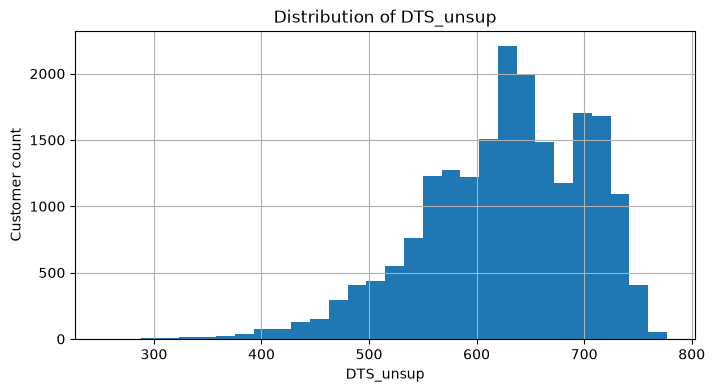

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(submission_unsup["DTS_unsup"], bins=30)
plt.xlabel("DTS_unsup")
plt.ylabel("Customer count")
plt.title("Distribution of DTS_unsup")
plt.grid(True)
plt.show()

In [10]:
submission_unsup[["AnomalyScore", "DTS_unsup"]].corr(method="spearman")

,AnomalyScore,DTS_unsup
AnomalyScore,1.000000,-0.307288
DTS_unsup,-0.307288,1.000000


In [11]:
extreme_cols = [
    "CustomerID",
    "AnomalyScore",
    "DTS_unsup",
    "device_score",
    "sim_score",
    "behavior_score",
    "identity_score",
    "device_risk",
    "sim_risk",
    "behavior_risk",
    "identity_risk",
]

score_output[extreme_cols].nsmallest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
10989,3221866,0.920863,253,306.702885,136.311667,481.680625,76.338462,0.693297,0.863688,0.518319,0.923662
3442,3069734,0.937782,288,292.145192,136.231667,438.448750,320.311538,0.707855,0.863768,0.561551,0.679688
14917,3302786,0.895123,295,448.837500,122.813333,523.373125,76.338462,0.551162,0.877187,0.476627,0.923662
17622,3356802,0.971345,297,432.949038,120.478333,550.645000,76.338462,0.567051,0.879522,0.449355,0.923662
9992,3201230,0.850932,298,508.629808,84.055000,523.193750,76.338462,0.491370,0.915945,0.476806,0.923662
19544,3390754,0.922168,300,527.860577,74.806667,269.616875,390.165385,0.472139,0.925193,0.730383,0.609835
11382,3229674,0.933867,301,508.629808,77.630000,272.843750,413.005769,0.491370,0.922370,0.727156,0.586994
14023,3284506,0.725472,305,463.395192,139.233333,527.341875,76.338462,0.536605,0.860767,0.472658,0.923662
6164,3124462,0.994803,307,20.645192,518.780000,348.681250,294.932692,0.979355,0.481220,0.651319,0.705067
3788,3077146,0.866592,312,527.860577,121.510000,515.105625,76.338462,0.472139,0.878490,0.484894,0.923662


In [12]:
score_output[extreme_cols].nlargest(
    20,
    "DTS_unsup",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
8503,3171402,0.138717,777,870.499038,708.796667,653.291875,917.788462,0.129501,0.291203,0.346708,0.082212
102,3002354,0.913843,776,870.499038,740.068333,609.610000,917.788462,0.129501,0.259932,0.390390,0.082212
1782,3035742,0.781543,775,870.499038,733.543333,627.440000,904.271154,0.129501,0.266457,0.372560,0.095729
6553,3132182,0.363223,773,870.499038,721.678333,647.586875,885.521154,0.129501,0.278322,0.352413,0.114479
19549,3390802,0.414477,771,870.499038,730.570000,602.750000,917.788462,0.129501,0.269430,0.397250,0.082212
3459,3070194,0.819252,769,870.499038,721.678333,617.216250,902.903846,0.129501,0.278322,0.382784,0.097096
4667,3094330,0.309852,769,870.499038,725.393333,602.219375,917.788462,0.129501,0.274607,0.397781,0.082212
10834,3218638,0.229213,768,870.499038,706.416667,648.614375,882.498077,0.129501,0.293583,0.351386,0.117502
19708,3393638,0.125848,768,870.499038,735.876667,614.002500,879.625000,0.129501,0.264123,0.385997,0.120375
3203,3064394,0.381493,767,870.499038,727.075000,589.291250,917.788462,0.129501,0.272925,0.410709,0.082212


In [13]:
score_output[extreme_cols].nlargest(
    20,
    "AnomalyScore",
)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
2593,3052314,0.999833,406,151.137500,729.440000,362.746250,295.117308,0.848863,0.270560,0.637254,0.704883
584,3011570,0.999622,340,151.137500,739.028333,259.184375,76.338462,0.848863,0.260972,0.740816,0.923662
4256,3086598,0.998965,352,392.218269,515.536667,47.918750,435.171154,0.607782,0.484463,0.952081,0.564829
2262,3045542,0.998645,418,392.218269,732.563333,340.973125,76.338462,0.607782,0.267437,0.659027,0.923662
14617,3297230,0.998583,470,392.218269,473.326667,330.260625,737.615385,0.607782,0.526673,0.669739,0.262385
376,3007294,0.998297,432,772.046154,329.318333,499.863125,76.338462,0.227954,0.670682,0.500137,0.923662
11779,3238626,0.997645,349,151.137500,149.696667,394.621250,837.642308,0.848863,0.850303,0.605379,0.162358
19942,3398714,0.997552,351,151.137500,734.410000,311.930625,76.338462,0.848863,0.265590,0.688069,0.923662
400,3007822,0.997505,459,487.620192,738.626667,400.175000,76.338462,0.512380,0.261373,0.599825,0.923662
14556,3295838,0.997495,401,327.891346,694.246667,383.568125,76.338462,0.672109,0.305753,0.616432,0.923662


In [14]:
score_output[
    (score_output["AnomalyScore"] >= score_output["AnomalyScore"].quantile(0.96))
    & (score_output["DTS_unsup"] >= score_output["DTS_unsup"].quantile(0.75))
][extreme_cols].sort_values("AnomalyScore", ascending=False).head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
10376,3209150,0.992155,698,793.089423,701.116667,550.741250,759.959615,0.206911,0.298883,0.449259,0.240040
1732,3034578,0.987415,690,702.393269,735.200000,594.646250,725.361538,0.297607,0.264800,0.405354,0.274638
286,3005526,0.984560,699,704.122115,739.743333,653.291875,689.332692,0.295878,0.260257,0.346708,0.310667
486,3009646,0.967940,723,794.818269,738.626667,582.483750,784.715385,0.205182,0.261373,0.417516,0.215285
19769,3395318,0.956553,697,779.802885,737.113333,431.730625,867.134615,0.220197,0.262887,0.568269,0.132865
5974,3120966,0.954863,734,793.089423,721.678333,653.291875,780.440385,0.206911,0.278322,0.346708,0.219560
16357,3330830,0.951340,698,870.499038,690.080000,433.150625,826.028846,0.129501,0.309920,0.566849,0.173971
17435,3353246,0.950760,697,702.393269,686.195000,568.154375,866.603846,0.297607,0.313805,0.431846,0.133396
11694,3237198,0.947705,689,704.122115,690.080000,518.506875,879.261538,0.295878,0.309920,0.481493,0.120738
6146,3124206,0.944960,703,870.499038,713.246667,370.952500,893.534615,0.129501,0.286753,0.629048,0.106465


In [15]:
score_output[
    (score_output["DTS_unsup"] <= score_output["DTS_unsup"].quantile(0.10))
    & (score_output["AnomalyScore"] <= score_output["AnomalyScore"].quantile(0.50))
][extreme_cols].sort_values("DTS_unsup").head(20)

,CustomerID,AnomalyScore,DTS_unsup,device_score,sim_score,behavior_score,identity_score,device_risk,sim_risk,behavior_risk,identity_risk
10317,3207730,0.369208,356,527.860577,72.806667,498.961250,388.809615,0.472139,0.927193,0.501039,0.611190
12197,3247402,0.406828,369,448.090385,338.321667,561.910000,76.338462,0.551910,0.661678,0.438090,0.923662
13296,3269282,0.439588,371,463.395192,134.111667,546.040625,392.917308,0.536605,0.865888,0.453959,0.607083
7497,3151654,0.433962,376,527.860577,100.818333,538.465000,394.180769,0.472139,0.899182,0.461535,0.605819
9486,3190998,0.300538,392,779.802885,154.068333,540.721875,76.338462,0.220197,0.845932,0.459278,0.923662
13031,3263910,0.492553,394,463.395192,128.575000,579.938750,470.582692,0.536605,0.871425,0.420061,0.529417
12515,3253398,0.451692,395,779.802885,150.653333,559.844375,76.338462,0.220197,0.849347,0.440156,0.923662
13923,3282310,0.361152,399,527.860577,141.283333,581.496250,397.832692,0.472139,0.858717,0.418504,0.602167
18641,3375078,0.387298,399,779.802885,125.791667,602.750000,76.338462,0.220197,0.874208,0.397250,0.923662
12365,3250646,0.381088,403,527.860577,336.101667,620.778750,76.338462,0.472139,0.663898,0.379221,0.923662


In [16]:
submission_unsup.to_csv(
    OUTPUT_DIR / "trackA_holdout_submission.csv",
    index=False,
)

score_output.to_csv(
    OUTPUT_DIR / "dts_unsup_with_pillars.csv",
    index=False,
)

print("Saved:")
print(OUTPUT_DIR / "trackA_holdout_submission.csv")
print(OUTPUT_DIR / "dts_unsup_with_pillars.csv")

Saved:
../outputs/trackA_holdout_submission.csv
../outputs/dts_unsup_with_pillars.csv
